In [1]:
import pandas as pd
from scipy.stats import percentileofscore
import matplotlib.pyplot as plt

In [2]:
def calculate_lsbl_from_triads(focal_v_pop2, focal_v_pop3, pop2_v_pop_3, output_file):
    df1 = pd.read_csv(focal_v_pop2, delim_whitespace=True, usecols=['CHROM', 'POS', 'WEIR_AND_COCKERHAM_FST'])
    df2 = pd.read_csv(focal_v_pop3, delim_whitespace=True, usecols=['CHROM', 'POS', 'WEIR_AND_COCKERHAM_FST'])
    df3 = pd.read_csv(pop2_v_pop_3, delim_whitespace=True, usecols=['CHROM', 'POS', 'WEIR_AND_COCKERHAM_FST'])

    df1.rename(columns={'WEIR_AND_COCKERHAM_FST': 'Fst_1'}, inplace=True)
    df2.rename(columns={'WEIR_AND_COCKERHAM_FST': 'Fst_2'}, inplace=True)
    df3.rename(columns={'WEIR_AND_COCKERHAM_FST': 'Fst_3'}, inplace=True)

    merged = df1.merge(df2, on=['CHROM', 'POS']).merge(df3, on=['CHROM', 'POS'])

    merged['LSBL'] = (merged['Fst_1'] + merged['Fst_2'] - merged['Fst_3']) / 2

    lsbl_values = merged['LSBL'].dropna().values
    pvals = [2 * min(
                (percentileofscore(lsbl_values, v, kind='mean') / 100),
                1 - (percentileofscore(lsbl_values, v, kind='mean') / 100)
            ) for v in merged['LSBL']]

    merged['p_empirical'] = pvals

    merged[['CHROM', 'POS', 'LSBL', 'p_empirical']].to_csv(output_file, index=False)
    print(f"Saved LSBL + p-values to {output_file}")

    return merged[['CHROM', 'POS', 'LSBL', 'p_empirical']]

In [6]:
lsbl = calculate_lsbl_from_triads('kaz_v_asian.weir.fst',
                           'kaz_v_eur.weir.fst',
                           'asian_v_eur.weir.fst',
                           'lsbl_kaz_eur_eas.csv')

/var/folders/vz/rlwzk9b96rq1c7f4whbh21t00000gn/T/ipykernel_94331/4273735724.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df1 = pd.read_csv(focal_v_pop2, delim_whitespace=True, usecols=['CHROM', 'POS', 'WEIR_AND_COCKERHAM_FST'])
/var/folders/vz/rlwzk9b96rq1c7f4whbh21t00000gn/T/ipykernel_94331/4273735724.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv(focal_v_pop3, delim_whitespace=True, usecols=['CHROM', 'POS', 'WEIR_AND_COCKERHAM_FST'])
/var/folders/vz/rlwzk9b96rq1c7f4whbh21t00000gn/T/ipykernel_94331/4273735724.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df3 = pd.read_csv(pop2_v_pop_3, delim_whitespace=True, usecols=['CHROM', 'POS', 'WEIR_AND_COCKERHAM_FST'])


Saved LSBL + p-values to lsbl_kaz_eur_eas.csv


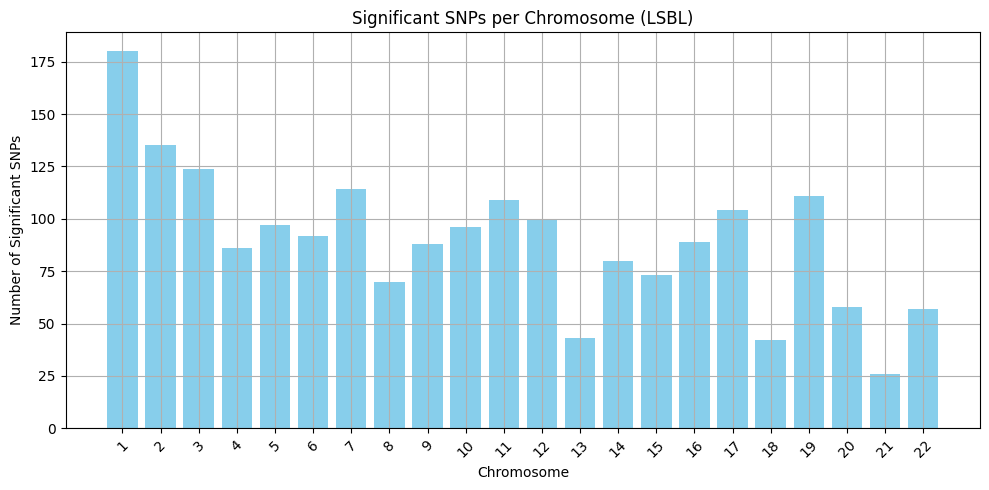

In [7]:
sig_snp = lsbl[lsbl['p_empirical'] < 0.05].copy()
sig_snp['CHROM'] = sig_snp['CHROM'].astype(str)
sig_snp['POS'] = sig_snp['POS'].astype(int)

chrom_order = [str(i) for i in range(1, 23)]
sig_snp['CHROM'] = pd.Categorical(sig_snp['CHROM'], categories=chrom_order, ordered=True)

chr_counts = sig_snp['CHROM'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(chr_counts.index, chr_counts.values, color='skyblue')
plt.xlabel('Chromosome')
plt.ylabel('Number of Significant SNPs')
plt.title('Significant SNPs per Chromosome (LSBL)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()

In [25]:
anno = pd.read_csv("../../top_snps.LATEST.annovar.hg19_multianno.header.txt", sep = '\t')
anno = anno[anno["avsnp151"] != "."]
df_with_rsid = anno[anno["avsnp151"].notna()]

sig_snp['CHROM'] = sig_snp['CHROM'].astype(int)
overlap_df = sig_snp.merge(df_with_rsid, left_on=["CHROM", "POS"], right_on=["Chr", "Start"])

overlap_df.to_csv ('lsbl_anno_overlap.csv', index=False)
overlap_exonic = overlap_df[
    (overlap_df['Func.refGene'] == 'exonic') &
    (overlap_df['ExonicFunc.refGene'] == 'nonsynonymous SNV')].copy()
overlap_exonic.to_csv ('lsbl_anno_overlap_nonsynonymous.csv', index=False)

In [28]:
lsbl_lenient = calculate_lsbl_from_triads('../fst_lenient/kaz_v_asian.weir.fst',
                           '../fst_lenient/kaz_v_eur.weir.fst',
                           '../fst_lenient/asian_v_eur.weir.fst',
                           '../fst_lenient/lsbl_kaz_eur_eas.csv')

/var/folders/vz/rlwzk9b96rq1c7f4whbh21t00000gn/T/ipykernel_94331/4273735724.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df1 = pd.read_csv(focal_v_pop2, delim_whitespace=True, usecols=['CHROM', 'POS', 'WEIR_AND_COCKERHAM_FST'])
/var/folders/vz/rlwzk9b96rq1c7f4whbh21t00000gn/T/ipykernel_94331/4273735724.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv(focal_v_pop3, delim_whitespace=True, usecols=['CHROM', 'POS', 'WEIR_AND_COCKERHAM_FST'])
/var/folders/vz/rlwzk9b96rq1c7f4whbh21t00000gn/T/ipykernel_94331/4273735724.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df3 = pd.read_csv(pop2_v_pop_3, delim_whitespace=True, usecols=['CHROM', 'POS', 'WEIR_AND_COCKERHAM_FST'])


Saved LSBL + p-values to ../fst_lenient/lsbl_kaz_eur_eas.csv


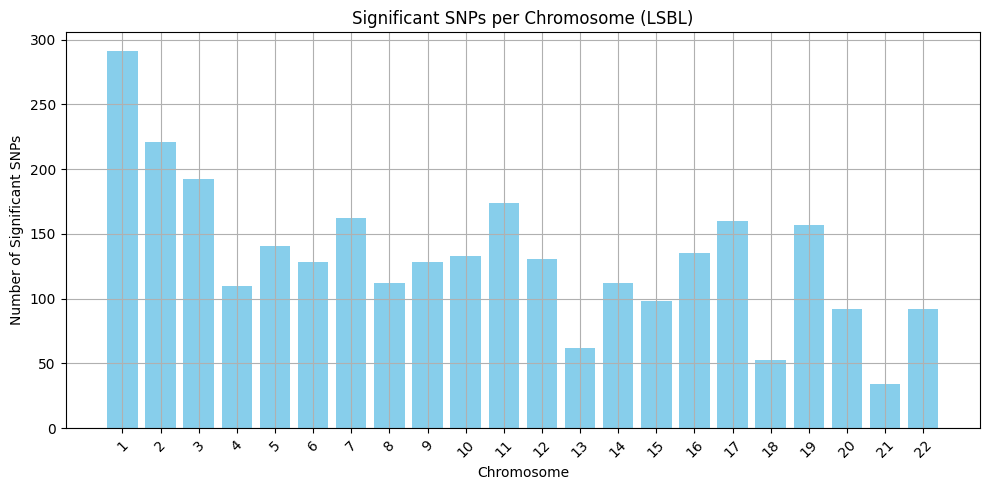

In [29]:
sig_snp_lenient = lsbl_lenient[lsbl_lenient['p_empirical'] < 0.05].copy()
sig_snp_lenient['CHROM'] = sig_snp_lenient['CHROM'].astype(str)
sig_snp_lenient['POS'] = sig_snp_lenient['POS'].astype(int)

sig_snp_lenient['CHROM'] = pd.Categorical(sig_snp_lenient['CHROM'], categories=chrom_order, ordered=True)

chr_counts_lenient = sig_snp_lenient['CHROM'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(chr_counts_lenient.index, chr_counts_lenient.values, color='skyblue')
plt.xlabel('Chromosome')
plt.ylabel('Number of Significant SNPs')
plt.title('Significant SNPs per Chromosome (LSBL)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()

In [39]:
sig_snp_lenient['CHROM'] = sig_snp_lenient['CHROM'].astype(int)

overlap_df_lenient = sig_snp_lenient.merge(df_with_rsid, left_on=["CHROM", "POS"], right_on=["Chr", "Start"])

overlap_df_lenient.to_csv ('../fst_lenient/lsbl_anno_overlap_lenient.csv', index=False)

overlap_exonic_lenient = overlap_df_lenient[
    (overlap_df_lenient['Func.refGene'] == 'exonic') &
    (overlap_df_lenient['ExonicFunc.refGene'] == 'nonsynonymous SNV')].copy()
overlap_exonic_lenient.to_csv ('../fst_lenient/lsbl_anno_overlap_nonsynonymous_lenient.csv', index=False)